<a href="https://colab.research.google.com/github/Shahidrrs/nutribone3/blob/main/nutribone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import random
import seaborn as sns

In [ ]:
import kagglehub

print("Downloading dataset 1 (mohamedgobara)...")
path1 = kagglehub.dataset_download("mohamedgobara/multi-class-knee-osteoporosis-x-ray-dataset")
print("Dataset 1 path:", path1)

print("\nDownloading dataset 2 (stevepython)...")
path2 = kagglehub.dataset_download("stevepython/osteoporosis-knee-xray-dataset")
print("Dataset 2 path:", path2)

Using Colab cache for faster access to the 'multi-class-knee-osteoporosis-x-ray-dataset' dataset.
Dataset 1 path: /kaggle/input/multi-class-knee-osteoporosis-x-ray-dataset

Using Colab cache for faster access to the 'osteoporosis-knee-xray-dataset' dataset.
Dataset 2 path: /kaggle/input/osteoporosis-knee-xray-dataset


In [ ]:
import random
import shutil
import os
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img

random.seed(42)
np.random.seed(42)

if os.path.exists("/tmp/osteoporosis_merged"):
    shutil.rmtree("/tmp/osteoporosis_merged")
    print("Old merged folder deleted.")

merged_dir = "/tmp/osteoporosis_merged"
splits     = ['train', 'val', 'test']
classes    = ['Normal', 'Osteopenia', 'Osteoporosis']

targets = {
    'train': 724,
    'val':   144,
    'test':  98
}

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(merged_dir, split, cls), exist_ok=True)

def collect_images(src_dir):
    if not os.path.exists(src_dir):
        print(f"  WARNING: Not found: {src_dir}")
        return []
    return [
        os.path.join(src_dir, f)
        for f in os.listdir(src_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]

def split_and_copy(image_paths, dst_class_dirs, label_prefix, train=0.75, val=0.15):
    random.shuffle(image_paths)
    n       = len(image_paths)
    n_train = int(n * train)
    n_val   = int(n * val)
    splits_map = {
        'train': image_paths[:n_train],
        'val':   image_paths[n_train:n_train + n_val],
        'test':  image_paths[n_train + n_val:]
    }
    counts = {}
    for split_name, paths in splits_map.items():
        dst = dst_class_dirs[split_name]
        for i, src in enumerate(paths):
            ext = os.path.splitext(src)[1].lower()
            shutil.copy2(src, os.path.join(dst, f"{label_prefix}_{i}{ext}"))
        counts[split_name] = len(paths)
    return counts

def augment_to_exact(src_dir, target_count, label_prefix='aug'):
    existing = [
        os.path.join(src_dir, f)
        for f in os.listdir(src_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ]
    current = len(existing)
    if current > target_count:
        to_remove = random.sample(existing, current - target_count)
        for f in to_remove:
            os.remove(f)
        print(f"  Trimmed {current} → {target_count}")
        return
    if current < target_count:
        aug = ImageDataGenerator(
            rotation_range=20,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.15,
            horizontal_flip=True,
            brightness_range=[0.8, 1.2],
            shear_range=0.1,
            fill_mode='nearest'
        )
        needed = target_count - current
        idx = 0
        print(f"  Augmenting {current} → {target_count} (need {needed})...")
        while idx < needed:
            src_img_path = random.choice(existing)
            try:
                img = load_img(src_img_path, target_size=(224, 224))
                x   = img_to_array(img).reshape((1, 224, 224, 3))
                for batch in aug.flow(x, batch_size=1):
                    Image.fromarray(batch[0].astype(np.uint8)).save(
                        os.path.join(src_dir, f"{label_prefix}_{idx}.jpg"))
                    idx += 1
                    break
            except Exception as e:
                continue
        print(f"  Done: {len(os.listdir(src_dir))} images")

d1_base    = os.path.join(path1, "OS Collected Data")
d1_sources = {
    'Normal':       os.path.join(d1_base, "Normal"),
    'Osteopenia':   os.path.join(d1_base, "Osteopenia"),
    'Osteoporosis': os.path.join(d1_base, "Osteoporosis"),
}
d2_sources = {
    'Normal':       os.path.join(path2, "normal", "normal"),
    'Osteoporosis': os.path.join(path2, "osteoporosis", "osteoporosis"),
}

for cls in classes:
    dst_dirs = {s: os.path.join(merged_dir, s, cls) for s in splits}
    imgs_d1  = collect_images(d1_sources.get(cls, ""))
    imgs_d2  = collect_images(d2_sources.get(cls, ""))
    counts1  = split_and_copy(imgs_d1, dst_dirs, label_prefix="d1")
    counts2  = split_and_copy(imgs_d2, dst_dirs, label_prefix="d2")
    print(f"\n{cls}: {len(imgs_d1)} D1 + {len(imgs_d2)} D2 = {len(imgs_d1)+len(imgs_d2)}")

print("\nBalancing classes...")
for cls in classes:
    for split_name in splits:
        target    = targets[split_name]
        split_dir = os.path.join(merged_dir, split_name, cls)
        augment_to_exact(split_dir, target, label_prefix=f'aug_{cls[:3].lower()}')

print("\nFinal summary:")
for split in splits:
    print(f"\n{split}/")
    for cls in classes:
        n = len(os.listdir(os.path.join(merged_dir, split, cls)))
        print(f"  {cls}: {n}")


Normal: 780 D1 + 186 D2 = 966

Osteopenia: 374 D1 + 0 D2 = 374

Osteoporosis: 793 D1 + 186 D2 = 979

Balancing classes...
  Augmenting 280 → 724 (need 444)...
  Done: 724 images
  Augmenting 56 → 144 (need 88)...
  Done: 144 images
  Augmenting 38 → 98 (need 60)...
  Done: 98 images
  Trimmed 733 → 724
  Trimmed 145 → 144
  Trimmed 101 → 98

Final summary:

train/
  Normal: 724
  Osteopenia: 724
  Osteoporosis: 724

val/
  Normal: 144
  Osteopenia: 144
  Osteoporosis: 144

test/
  Normal: 98
  Osteopenia: 98
  Osteoporosis: 98


In [ ]:
train_dir = os.path.join(merged_dir, 'train')
val_dir   = os.path.join(merged_dir, 'val')
test_dir  = os.path.join(merged_dir, 'test')

def make_generators(preprocess_fn, batch_size=16):
    train_datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.85, 1.15],
        fill_mode='nearest',
        preprocessing_function=preprocess_fn
    )
    val_datagen  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_fn)

    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=(224, 224), batch_size=batch_size,
        classes=['Normal', 'Osteopenia', 'Osteoporosis'],
        class_mode='categorical', shuffle=True
    )
    val_gen = val_datagen.flow_from_directory(
        val_dir, target_size=(224, 224), batch_size=batch_size,
        classes=['Normal', 'Osteopenia', 'Osteoporosis'],
        class_mode='categorical', shuffle=False
    )
    test_gen = test_datagen.flow_from_directory(
        test_dir, target_size=(224, 224), batch_size=1,
        classes=['Normal', 'Osteopenia', 'Osteoporosis'],
        class_mode='categorical', shuffle=False
    )
    return train_gen, val_gen, test_gen

def build_model(backbone, preprocess_fn_name):
    inputs     = layers.Input(shape=(224, 224, 3))
    backbone.trainable = False
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    return models.Model(inputs, outputs)

print("Helper functions ready.")

Helper functions ready.


In [5]:
print("=" * 50)
print("TRAINING MODEL 1: VGG-19")
print("=" * 50)

preprocess_vgg = tf.keras.applications.vgg19.preprocess_input
train_gen, val_gen, test_gen = make_generators(preprocess_vgg)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights_array))

# Build VGG-19
vgg_base = tf.keras.applications.VGG19(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_vgg = build_model(vgg_base, 'vgg19')

# Stage 1
model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_s1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("vgg19_stage1.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nVGG-19 Stage 1...")
h_vgg1 = model_vgg.fit(train_gen, validation_data=val_gen,
                        epochs=20, callbacks=cb_s1,
                        class_weight=class_weights)

# Stage 2 — unfreeze block4 + block5
vgg_base.trainable = True
for layer in vgg_base.layers:
    layer.trainable = 'block5' in layer.name or 'block4' in layer.name

model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_s2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("vgg19_best.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nVGG-19 Stage 2...")
h_vgg2 = model_vgg.fit(train_gen, validation_data=val_gen,
                        epochs=40, callbacks=cb_s2,
                        class_weight=class_weights)

print(f"\nVGG-19 Best Val Accuracy: {max(h_vgg2.history['val_accuracy']):.4f}")

TRAINING MODEL 1: VGG-19
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

VGG-19 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.5316 - loss: 1.3475
Epoch 1: val_accuracy improved from None to 0.72917, saving model to vgg19_stage1.keras

Epoch 1: finished saving model to vgg19_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 117s 757ms/step - accuracy: 0.5971 - loss: 1.2118 - val_accuracy: 0.7292 - val_loss: 0.7107 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.6213 - loss: 0.9887
Epoch 2: val_accuracy improved from 0.72917 to 0.74769, saving model to vgg19_stage1.keras

Epoch 2: finished saving model to vgg19_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 92s 678ms/step - accuracy: 0.6381 - loss: 0.9535 - val_accuracy: 0.7477 - val_loss: 0.6804 - learning_rate: 0.0010
Epoch 3/20
136/136 ━━━━━━━━━━

In [6]:
print("=" * 50)
print("TRAINING MODEL 2: ResNet50")
print("=" * 50)

preprocess_res = tf.keras.applications.resnet50.preprocess_input
train_gen_r, val_gen_r, test_gen_r = make_generators(preprocess_res)

res_base = tf.keras.applications.ResNet50(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3))
model_res = build_model(res_base, 'resnet50')

# Stage 1
model_res.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r1 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint("resnet50_stage1.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nResNet50 Stage 1...")
h_res1 = model_res.fit(train_gen_r, validation_data=val_gen_r,
                        epochs=20, callbacks=cb_r1,
                        class_weight=class_weights)

# Stage 2 — unfreeze last 40 layers
res_base.trainable = True
for layer in res_base.layers[:-40]:
    layer.trainable = False

model_res.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='categorical_crossentropy', metrics=['accuracy'])

cb_r2 = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-9, verbose=1),
    ModelCheckpoint("resnet50_best.keras", monitor='val_accuracy',
                    save_best_only=True, verbose=1)
]
print("\nResNet50 Stage 2...")
h_res2 = model_res.fit(train_gen_r, validation_data=val_gen_r,
                        epochs=40, callbacks=cb_r2,
                        class_weight=class_weights)

print(f"\nResNet50 Best Val Accuracy: {max(h_res2.history['val_accuracy']):.4f}")

TRAINING MODEL 2: ResNet50
Found 2172 images belonging to 3 classes.
Found 432 images belonging to 3 classes.
Found 294 images belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step

ResNet50 Stage 1...
Epoch 1/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.6415 - loss: 1.1723
Epoch 1: val_accuracy improved from None to 0.77546, saving model to resnet50_stage1.keras

Epoch 1: finished saving model to resnet50_stage1.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 117s 736ms/step - accuracy: 0.6717 - loss: 1.0765 - val_accuracy: 0.7755 - val_loss: 0.6751 - learning_rate: 0.0010
Epoch 2/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.6963 - loss: 0.8957
Epoch 2: val_accuracy did not improve from 0.77546
136/136 ━━━━━━━━━━━━━━━━━━━━ 89s 653ms/step - accuracy: 0.7035 - loss: 0.8715 - val_accuracy: 0.7708 - val_loss: 0.6483 - learning_rate: 0.0010
Epoch 3/20
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.7295 - loss: 0.8067
Epoch 3: val_accuracy imp

In [7]:
print("Loading all 4 best models...")
m_vgg  = tf.keras.models.load_model("vgg19_best.keras")
m_res  = tf.keras.models.load_model("resnet50_best.keras")


class_names = ['Normal', 'Osteopenia', 'Osteoporosis']

def get_preds(model, preprocess_fn, n_tta=20):
    """Get TTA predictions from a model."""
    tta_datagen = ImageDataGenerator(
        rotation_range=5,
        horizontal_flip=True,
        zoom_range=0.03,
        preprocessing_function=preprocess_fn
    )
    # Get total test samples
    total = sum(
        len(os.listdir(os.path.join(test_dir, cls)))
        for cls in ['Normal', 'Osteopenia', 'Osteoporosis']
    )
    preds = np.zeros((total, 3))

    for i in range(n_tta):
        gen = tta_datagen.flow_from_directory(
            test_dir, target_size=(224, 224), batch_size=1,
            classes=['Normal', 'Osteopenia', 'Osteoporosis'],
            class_mode='categorical', shuffle=False)
        gen.reset()
        preds += model.predict(gen, steps=len(gen), verbose=0)
        print(f"  TTA round {i+1}/{n_tta} done")
    return preds / n_tta

# VGG-19 and ResNet50 are strongest — give them 30 TTA rounds
print("\nVGG-19 predictions (30 TTA rounds)...")
preds_vgg = get_preds(m_vgg,
                      tf.keras.applications.vgg19.preprocess_input,
                      n_tta=30)

print("\nResNet50 predictions (30 TTA rounds)...")
preds_res = get_preds(m_res,
                      tf.keras.applications.resnet50.preprocess_input,
                      n_tta=30)


# Get true labels
label_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg19.preprocess_input
).flow_from_directory(
    test_dir, target_size=(224, 224), batch_size=1,
    classes=['Normal', 'Osteopenia', 'Osteoporosis'],
    class_mode='categorical', shuffle=False)
y_true = label_gen.classes

print("\nAll predictions done!")

Loading all 4 best models...

VGG-19 predictions (30 TTA rounds)...
Found 294 images belonging to 3 classes.
  TTA round 1/30 done
Found 294 images belonging to 3 classes.
  TTA round 2/30 done
Found 294 images belonging to 3 classes.
  TTA round 3/30 done
Found 294 images belonging to 3 classes.
  TTA round 4/30 done
Found 294 images belonging to 3 classes.
  TTA round 5/30 done
Found 294 images belonging to 3 classes.
  TTA round 6/30 done
Found 294 images belonging to 3 classes.
  TTA round 7/30 done
Found 294 images belonging to 3 classes.
  TTA round 8/30 done
Found 294 images belonging to 3 classes.
  TTA round 9/30 done
Found 294 images belonging to 3 classes.
  TTA round 10/30 done
Found 294 images belonging to 3 classes.
  TTA round 11/30 done
Found 294 images belonging to 3 classes.
  TTA round 12/30 done
Found 294 images belonging to 3 classes.
  TTA round 13/30 done
Found 294 images belonging to 3 classes.
  TTA round 14/30 done
Found 294 images belonging to 3 classes.
  TT


Searching for optimal 2-model ensemble weights...
(This may take less than 5 seconds)

Best weights:
  VGG-19:   0.2
  ResNet50: 0.8

Best 2-Model Ensemble Accuracy: 87.76%

--- Final 2-Model Ensemble Classification Report ---
              precision    recall  f1-score   support

      Normal       0.96      0.87      0.91        98
  Osteopenia       0.89      0.86      0.88        98
Osteoporosis       0.80      0.91      0.85        98

    accuracy                           0.88       294
   macro avg       0.88      0.88      0.88       294
weighted avg       0.88      0.88      0.88       294



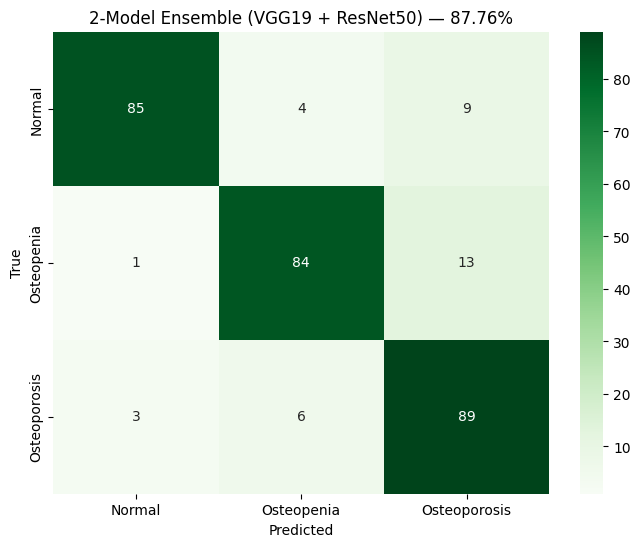

In [8]:
print("\nSearching for optimal 2-model ensemble weights...")
print("(This may take less than 5 seconds)")

best_acc   = 0
best_w     = (1, 1)
best_preds = None

# Search weight combinations ONLY for Model 1 (VGG-19) and Model 2 (ResNet50)
for w1 in np.arange(0.2, 1.3, 0.2):      # VGG-19
    for w2 in np.arange(0.2, 1.3, 0.2):   # ResNet50
        # Combine only the first two models
        ensemble = (w1 * preds_vgg + w2 * preds_res)

        y_pred   = np.argmax(ensemble, axis=1)
        acc      = np.sum(y_pred == y_true) / len(y_true)

        if acc > best_acc:
            best_acc   = acc
            best_w     = (w1, w2)
            best_preds = ensemble.copy()

print(f"\nBest weights:")
print(f"  VGG-19:   {best_w[0]:.1f}")
print(f"  ResNet50: {best_w[1]:.1f}")
print(f"\nBest 2-Model Ensemble Accuracy: {best_acc * 100:.2f}%")

y_pred_final = np.argmax(best_preds, axis=1)

print("\n--- Final 2-Model Ensemble Classification Report ---")
print(classification_report(y_true, y_pred_final, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'2-Model Ensemble (VGG19 + ResNet50) — {best_acc*100:.2f}%')
plt.show()
